In [1]:
import sys
from pathlib import Path
from typing import Dict, Any

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "esc50" / "data")

print(f"Current directory: {current_dir}")
print(f"Project root: {project_root}")
print(f"Data root: {data_root}")

Current directory: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/notebooks/esc50
Project root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4
Data root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data


In [2]:
from esc50_task import ESC50Task
from src.train_utils.trainer import Trainer
from src.utils.block_factory import make_s4_block_cfg_ctor

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


In [3]:
from src.utils.common import device_auto

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 32,
    "data_loader_kwargs": {
        "num_workers": 0,
        "fold_val": 1,
        "feature": "melspec",
        "sample_rate": 16000,
        "n_mels": 128,
        "hop_length": 160,
        "n_fft": 512,
        "target_num_frames": 500,
        "augment": True,
        "pin_memory": False,
        "persistent_workers": False,
    },

    "epochs": 100,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": True,
    "save_dir": "./runs/esc50_s4_task",
    "warmup_epochs": 10,
    "patience": 10,
    "min_delta": 0.0,
    "early_key": "acc",

    "d_model": 256,
    "depth": 4,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.05,
    "layerscale_init": 1e-2,
    "residual_gain": 1.0,
    "pool": "mean",

    # S4-specific parameters
    "d_state": 64,
    "channels": 2,
    "mode": 's4d',
    "dt_min": 0.001,
    "dt_max": 0.1,
}

args["block_cfg_ctor"] = make_s4_block_cfg_ctor(
    **args,
)

args = device_auto(args)

Using MPS


In [ ]:
task = ESC50Task()

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"✅ Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...
Loaded checkpoint from epoch 78
Val metrics: {'loss': 2.1794225215911864, 'time_s': 3.8839452499996696, 'acc': 0.56}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


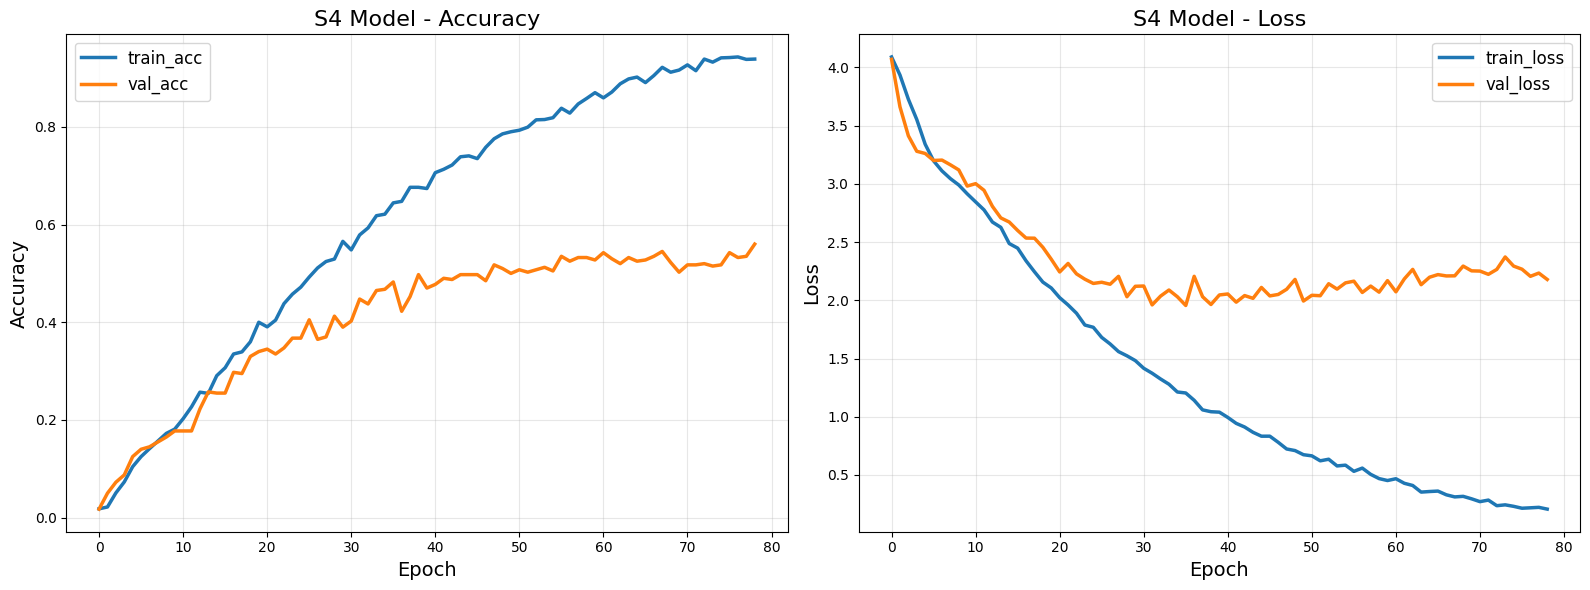

In [4]:
from src.utils.visualization import plot_classification_history
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=ESC50Task(),
)

plot_classification_history(trainer.history, model_name="S4")

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...
Loaded checkpoint from epoch 78
Val metrics: {'loss': 2.1794225215911864, 'time_s': 3.8839452499996696, 'acc': 0.56}
ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecod

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(



   Validation Accuracy: 0.5600 (56.00%)
   Validation Loss: 2.1794

VALIDATION SET RESULTS
Overall accuracy: 0.5600
Num classes: 50

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_30                  : 1.000
02. class_19                  : 1.000
03. class_9                   : 1.000
04. class_34                  : 1.000
05. class_18                  : 0.875
06. class_12                  : 0.750
07. class_3                   : 0.750
08. class_42                  : 0.750
09. class_39                  : 0.750
10. class_17                  : 0.750
Bottom per-class accuracies:
01. class_40                  : 0.125
02. class_15                  : 0.250
03. class_48                  : 0.250
04. class_46                  : 0.250
05. class_7                   : 0.250
06. class_35                  : 0.250
07. class_23                  : 0.250
08. class_45                  : 0.375
09. class_41                  : 0.375
10. class_6                   : 0.375


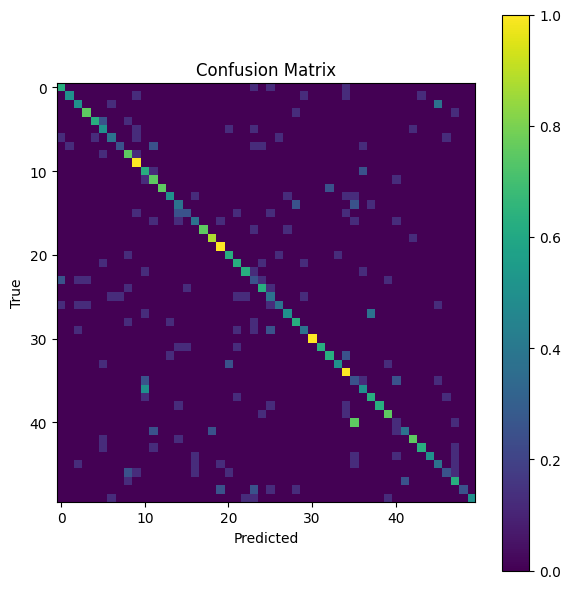

In [5]:
from src.eval.eval_utils import evaluate_classification_model

best_model_path = args["save_dir"] + "/best.pt"
all_logits, all_labels = evaluate_classification_model(
    args=args,
    task=ESC50Task(),
    best_model_path=best_model_path,
    num_classes=50,
    save_results=True,
    use_test_set=False
)

In [5]:
from src.utils.common import print_model_details

print_model_details(model=trainer.model)


                            MODEL DETAILS                             

                             ARCHITECTURE                             
----------------------------------------------------------------------
Model Type: SeqClassifier
Core Layer Type: S4CoreAdapter
Number of Blocks: 4

                              PARAMETERS                              
----------------------------------------------------------------------
Total parameters:              2,946,354
Trainable parameters:          2,946,354
Non-trainable parameters:              0
Model size (MB):                   11.24

                           MODEL ATTRIBUTES                           
----------------------------------------------------------------------

                           MODULE BREAKDOWN                           
----------------------------------------------------------------------
proj                           Linear                             33,024
blocks                         ModuleList 

### Changes in dataset length


Training with fraction: 0.75
ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...
   Applying data fraction: 75.0%
   Original train size: 1600
   Original val size: 400


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ 

   Reduced train size: 1200
   Reduced val size: 400
   Test size: 400 (unchanged)


...

Epoch 073/100 | train 0.3395/0.9062 | val 2.4094/0.4625 | t 26.3s/3.1s | lr 2.06e-04


Epoch 074/100 | train 0.3430/0.9096 | val 2.3803/0.4800 | t 26.2s/3.1s | lr 1.92e-04


Epoch 075/100 | train 0.3259/0.9046 | val 2.3785/0.5050 | t 26.3s/3.1s | lr 1.79e-04


Epoch 076/100 | train 0.3085/0.9113 | val 2.3391/0.5050 | t 26.2s/3.1s | lr 1.65e-04


⏹ Early stopping (patience=10, best=0.5125).
📊 Training history saved to ./runs/esc50_s4_task_frac_0.75/history.json

Training complete for fraction 0.75! Best validation acc: 0.5125
Best model saved to: ./runs/esc50_s4_task_frac_0.75/best.pt


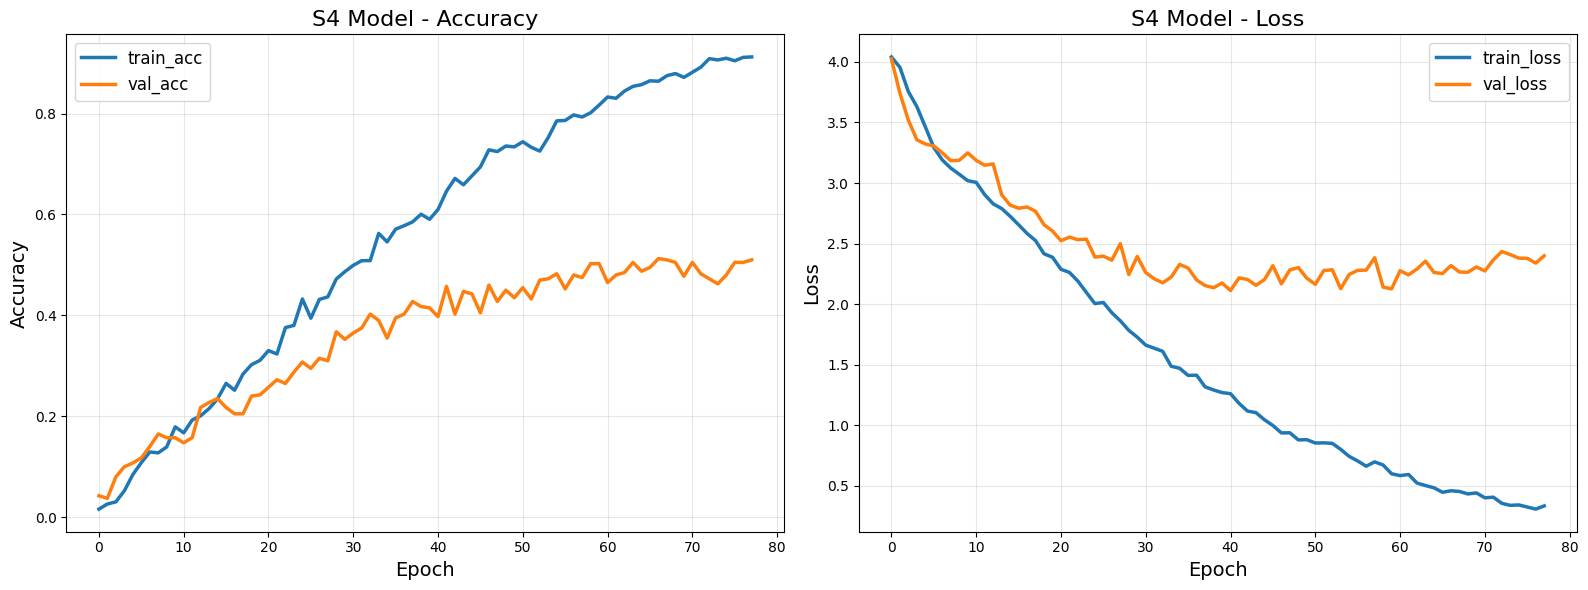

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...
   Applying data fraction: 75.0%
   Original train size: 1600
   Original val size: 400


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


   Reduced train size: 1200
   Reduced val size: 400
   Test size: 400 (unchanged)
Loaded checkpoint from epoch 66
Val metrics: {'loss': 2.3189414954185485, 'time_s': 3.1242795840003055, 'acc': 0.5125}
ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecod

ESC-50 check under /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data. Checking /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/esc50/data/ESC-50-master ...


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(



   Validation Accuracy: 0.5125 (51.25%)
   Validation Loss: 2.3189

VALIDATION SET RESULTS
Overall accuracy: 0.5125
Num classes: 50

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_9                   : 1.000
02. class_30                  : 1.000
03. class_34                  : 0.875
04. class_11                  : 0.875
05. class_17                  : 0.875
06. class_19                  : 0.875
07. class_4                   : 0.750
08. class_39                  : 0.750
09. class_8                   : 0.750
10. class_10                  : 0.750
Bottom per-class accuracies:
01. class_41                  : 0.000
02. class_46                  : 0.125
03. class_5                   : 0.125
04. class_7                   : 0.125
05. class_36                  : 0.125
06. class_21                  : 0.250
07. class_45                  : 0.250
08. class_40                  : 0.250
09. class_35                  : 0.250
10. class_14                  : 0.250


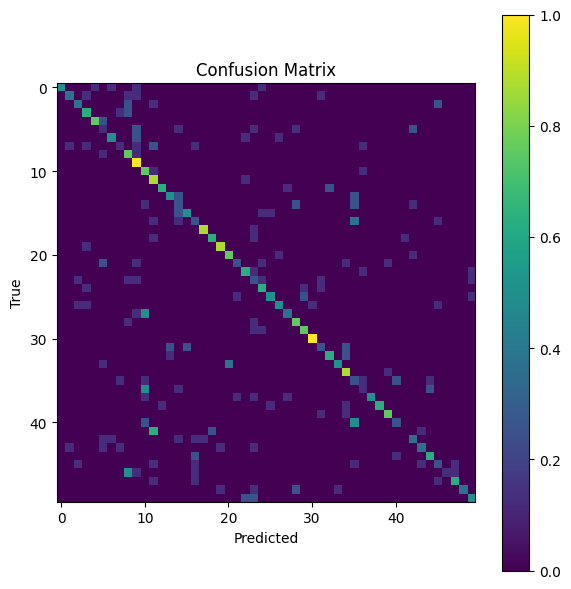

In [11]:
from src.eval.eval_utils import evaluate_classification_model
from src.utils.visualization import plot_classification_history

for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/esc50_s4_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=ESC50Task())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history

    plot_classification_history(history, model_name="S4")

    logits_test, labels_test = evaluate_classification_model(
        args=args,
        task=ESC50Task(),
        best_model_path=best_path,
        num_classes=50,
        save_results=True,
        use_test_set=False
    )